In [43]:
from pymo.parsers import BVHParser

parser = BVHParser()
#fbs  = 60
parsed_data = parser.parse('/home/ltdoanh/ldtan/Motion_Diffusion/datasets/BEAT/beat_english_v0.2.1/beat_english_v0.2.1/1/1_wayne_0_1_1.bvh')

In [40]:
from pymo.viz_tools import *

print_skel(parsed_data)

- Hips (None)
| | - LeftUpLeg (Hips)
| | - LeftLeg (LeftUpLeg)
| | - LeftFoot (LeftLeg)
| | - LeftForeFoot (LeftFoot)
| | - LeftToeBase (LeftForeFoot)
| | - LeftToeBaseEnd (LeftToeBase)
| | - LeftToeBaseEnd_Nub (LeftToeBaseEnd)
| - RightUpLeg (Hips)
| - RightLeg (RightUpLeg)
| - RightFoot (RightLeg)
| - RightForeFoot (RightFoot)
| - RightToeBase (RightForeFoot)
| - RightToeBaseEnd (RightToeBase)
| - RightToeBaseEnd_Nub (RightToeBaseEnd)
- Spine (Hips)
- Spine1 (Spine)
- Spine2 (Spine1)
- Spine3 (Spine2)
| | - LeftShoulder (Spine3)
| | - LeftArm (LeftShoulder)
| | - LeftForeArm (LeftArm)
| | - LeftHand (LeftForeArm)
| | | | - LeftHandIndex (LeftHand)
| | | | | - LeftHandThumb1 (LeftHandIndex)
| | | | | - LeftHandThumb2 (LeftHandThumb1)
| | | | | - LeftHandThumb3 (LeftHandThumb2)
| | | | | - LeftHandThumb4 (LeftHandThumb3)
| | | | | - LeftHandThumb4_Nub (LeftHandThumb4)
| | | | - LeftHandIndex1 (LeftHandIndex)
| | | | - LeftHandIndex2 (LeftHandIndex1)
| | | | - LeftHandIndex3 (LeftHandIn

In [44]:

from pymo.preprocessing import *
from sklearn.pipeline import Pipeline

data_pipe = Pipeline([
    ('param', MocapParameterizer('position')),
    # ('rcpn', RootCentricPositionNormalizer()),
    # ('delta', RootTransformer('abdolute_translation_deltas')),
    # ('const', ConstantsRemover()),
    ('np', Numpyfier()),
    # ('down', DownSampler(2)),
    # ('stdscale', ListStandardScaler())
])

piped_data = data_pipe.fit_transform([parsed_data])

/home/ltdoanh/ldtan/Motion_Diffusion/datasets/pymo/preprocessing.py:146: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pos_df['%s_Yposition'%joint] = pd.Series(data=[e[1] for e in tree_data[joint][1]], index=pos_df.index)
/home/ltdoanh/ldtan/Motion_Diffusion/datasets/pymo/preprocessing.py:147: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pos_df['%s_Zposition'%joint] = pd.Series(data=[e[2] for e in tree_data[joint][1]], index=pos_df.index)
/home/ltdoanh/ldtan/Motion_Diffusion/datasets/pymo/preprocessing.py:145: PerformanceWarnin

In [45]:
print(piped_data.shape) 

(1, 8280, 264)


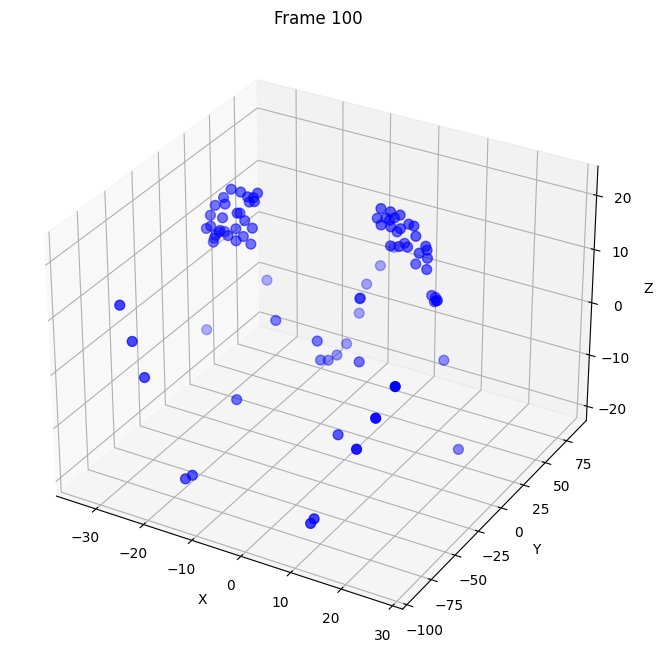

In [46]:
import matplotlib.pyplot as plt  
from mpl_toolkits.mplot3d import Axes3D  
  
# Load và reshape data  
motion_data = piped_data 
if motion_data.ndim == 3:  
    motion_data = motion_data[0]  
  
# Visualize frame cụ thể  
frame_idx = 100  
frame_data = motion_data[frame_idx].reshape(-1, 3)  # (joints, 3)  
  
fig = plt.figure(figsize=(10, 8))  
ax = fig.add_subplot(111, projection='3d')  
ax.scatter(frame_data[:, 0], frame_data[:, 1], frame_data[:, 2], c='blue', s=50)  
ax.set_xlabel('X')  
ax.set_ylabel('Y')  
ax.set_zlabel('Z')  
plt.title(f'Frame {frame_idx}')  
plt.show()

In [ ]:
mp = MocapParameterizer('position')

positions = mp.fit_transform([parsed_data])

In [13]:
positions[0]

<AxesSubplot:>

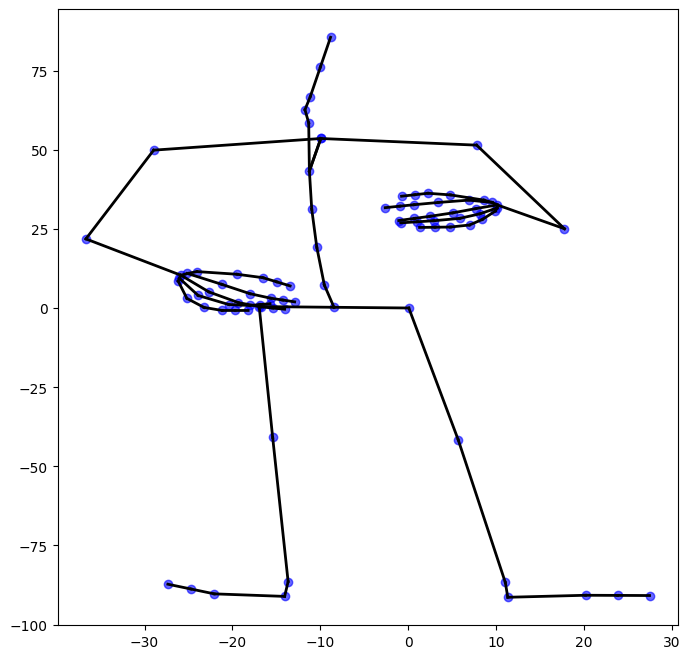

In [9]:
draw_stickfigure(positions[0], frame=120)

In [29]:
from pymo.preprocessing import *  
from sklearn.pipeline import Pipeline  
  
# Tạo pipeline với Numpyfier ở cuối  
data_pipe = Pipeline([  
    ('param', MocapParameterizer('position')),  
    ('rcpn', RootCentricPositionNormalizer()),  
    ('delta', RootTransformer('abdolute_translation_deltas')),  
    ('const', ConstantsRemover()),  
    ('np', Numpyfier()),  # Chuyển đổi sang numpy array  
    ('down', DownSampler(2)),  
    ('stdscale', ListStandardScaler())  
])  
  
# Áp dụng pipeline  
piped_data = data_pipe.fit_transform([parsed_data])  
  
# Xem shape  
print(piped_data.shape) 

/home/ltdoanh/ldtan/Motion_Diffusion/datasets/pymo/preprocessing.py:146: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pos_df['%s_Yposition'%joint] = pd.Series(data=[e[1] for e in tree_data[joint][1]], index=pos_df.index)
/home/ltdoanh/ldtan/Motion_Diffusion/datasets/pymo/preprocessing.py:147: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pos_df['%s_Zposition'%joint] = pd.Series(data=[e[2] for e in tree_data[joint][1]], index=pos_df.index)
/home/ltdoanh/ldtan/Motion_Diffusion/datasets/pymo/preprocessing.py:145: PerformanceWarnin

(1, 4140, 264)


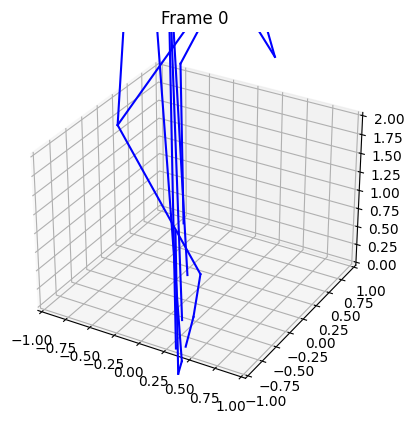

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

# Skeleton của BEAT dataset
BEAT_SKELETON = [
    (0, 1), (1, 2), (2, 3),       # Spine
    (1, 4), (4, 5), (5, 6),       # Left arm
    (1, 7), (7, 8), (8, 9),       # Right arm
    (0, 10), (10, 11), (11, 12),  # Left leg
    (0, 13), (13, 14), (14, 15),  # Right leg
    (2, 16), (16, 17), (17, 18),  # Neck & head
    (3, 19), (3, 20), (3, 21)     # Shoulders or face
]

def visualize_motion(motion_file, use_dim=66):
    motion = np.load(motion_file)  # shape: (1, T, 264) or (T, 264)

    if motion.ndim == 3:
        motion = motion[0]  # (T, 264)
    elif motion.ndim == 2:
        pass  # đã đúng rồi
    else:
        raise ValueError(f"Unexpected motion shape: {motion.shape}")

    motion = motion[:, :use_dim]  # (T, 66)
    motion = motion.reshape(motion.shape[0], 22, 3)  # (T, 22, 3)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for t in range(0, motion.shape[0], 2):  # giảm tần suất để nhẹ hơn
        ax.clear()
        joints = motion[t]

        for joint1, joint2 in BEAT_SKELETON:
            xs = [joints[joint1][0], joints[joint2][0]]
            ys = [joints[joint1][1], joints[joint2][1]]
            zs = [joints[joint1][2], joints[joint2][2]]
            ax.plot(xs, ys, zs, c='blue')

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_zlim(0, 2)
        ax.set_title(f"Frame {t}")
        plt.pause(0.01)

    plt.show()

# Ví dụ dùng:
visualize_motion("/home/ltdoanh/ldtan/Motion_Diffusion/datasets/sentence_segments/000_sentence.npy")


In [31]:
import numpy as np  
import pandas as pd  
from pymo.parsers import BVHParser  
from pymo.viz_tools import draw_stickfigure, nb_play_mocap  
  
# Load numpy data  
motion_data = np.load("/home/ltdoanh/ldtan/Motion_Diffusion/datasets/sentence_segments/000_sentence.npy")  
  
# Parse BVH file làm template (sử dụng file demo có sẵn)  
parser = BVHParser()  
template_mocap = parser.parse('/home/ltdoanh/ldtan/Motion_Diffusion/datasets/BEAT/beat_english_v0.2.1/beat_english_v0.2.1/1/1_wayne_0_1_1.bvh')  
  
# Xử lý shape của motion_data  
if motion_data.ndim == 3:  
    motion_data = motion_data[0]  # Lấy sequence đầu tiên  
  
# Thay thế data trong template  
template_mocap.values = pd.DataFrame(motion_data, columns=template_mocap.values.columns)  
  
# Visualize  
draw_stickfigure(template_mocap, frame=100)  
nb_play_mocap(template_mocap, 'pos')

ValueError: Shape of passed values is (326, 264), indices imply (326, 228)

KeyError: 'Spine_Xposition'

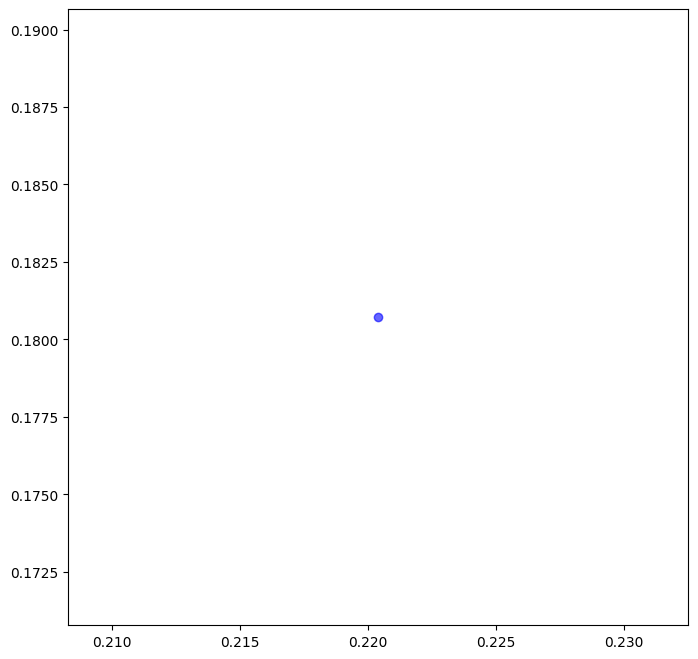

In [35]:
import numpy as np  
import pandas as pd  
from pymo.parsers import BVHParser  
from pymo.viz_tools import draw_stickfigure, nb_play_mocap  
  
# Load numpy data từ model bất kỳ  
generated_motion = np.load("/home/ltdoanh/ldtan/Motion_Diffusion/datasets/sentence_segments/000_sentence.npy")  
  
# Sử dụng template BVH  
parser = BVHParser()  
template_mocap = parser.parse('/home/ltdoanh/ldtan/Motion_Diffusion/datasets/BEAT/beat_english_v0.2.1/beat_english_v0.2.1/1/1_wayne_0_1_1.bvh')  
  
# Xử lý shape compatibility  
if generated_motion.ndim == 3:  
    generated_motion = generated_motion[0]  # Lấy sequence đầu tiên  
  
# Điều chỉnh số features nếu cần  
if generated_motion.shape[1] != len(template_mocap.values.columns):  
    # Cắt hoặc pad để match template  
    target_cols = len(template_mocap.values.columns)  
    if generated_motion.shape[1] > target_cols:  
        generated_motion = generated_motion[:, :target_cols]  
    else:  
        padding = np.zeros((generated_motion.shape[0], target_cols - generated_motion.shape[1]))  
        generated_motion = np.concatenate([generated_motion, padding], axis=1)  
  
# Thay thế data  
template_mocap.values = pd.DataFrame(generated_motion, columns=template_mocap.values.columns)  
  
# Visualize  
draw_stickfigure(template_mocap, frame=100)  
nb_play_mocap(template_mocap, 'pos')

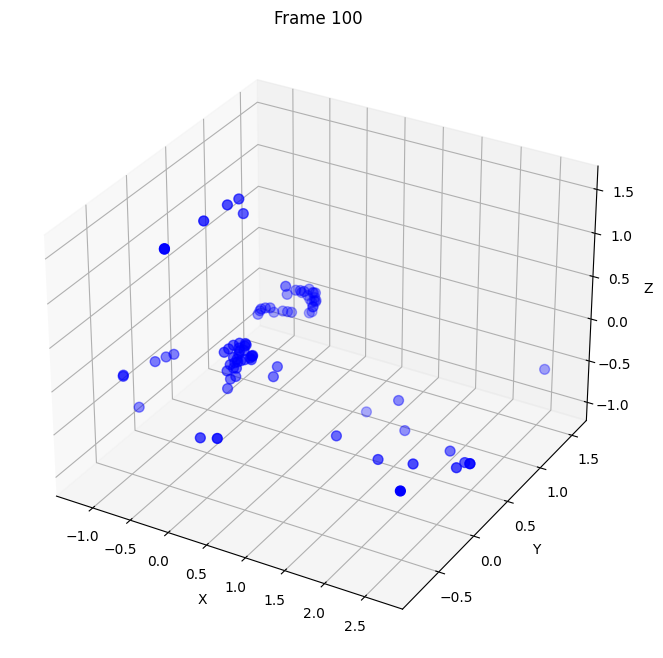

In [32]:
import matplotlib.pyplot as plt  
from mpl_toolkits.mplot3d import Axes3D  
  
# Giả sử motion_data có shape (frames, joints*3)  
frame_idx = 100  
frame_data = motion_data[frame_idx].reshape(-1, 3)  # (joints, 3)  
  
fig = plt.figure(figsize=(10, 8))  
ax = fig.add_subplot(111, projection='3d')  
ax.scatter(frame_data[:, 0], frame_data[:, 1], frame_data[:, 2], c='blue', s=50)  
ax.set_xlabel('X')  
ax.set_ylabel('Y')  
ax.set_zlabel('Z')  
plt.title(f'Frame {frame_idx}')  
plt.show()

In [ ]:
import os
import numpy as np
from textgrid import TextGrid

def time_to_frame(t, fps=60):
    return int(round(t * fps))

def extract_sentences_with_text(
    textgrid_path, text_path, motion_data, output_dir, fps=60, pause_threshold=0.5
):
    basename = os.path.splitext(os.path.basename(textgrid_path))[0]  # ví dụ: 1_wayne_0_1_1
    motion = motion_data[0]  # shape: (num_frames, 264)

    tg = TextGrid.fromFile(textgrid_path)
    tier = tg[0]  # chỉ lấy item[1]

    with open(text_path, 'r') as f:
        full_text = f.read().strip()

    os.makedirs(output_dir, exist_ok=True)

    sentence_start = None
    sentence_end = None
    sentence_text = []
    sentence_idx = 0

    for interval in tier.intervals:
        word = interval.mark.strip()
        xmin = float(interval.minTime)
        xmax = float(interval.maxTime)

        if word != "":
            if sentence_start is None:
                sentence_start = xmin
            sentence_end = xmax
            sentence_text.append(word)
        else:
            pause = xmax - xmin
            if pause >= pause_threshold and sentence_text:
                # Save motion
                start_frame = time_to_frame(sentence_start, fps)
                end_frame = time_to_frame(sentence_end, fps)
                motion_segment = motion[start_frame:end_frame, :]

                fname_base = f"{basename}_sentence_{sentence_idx:03d}"
                np.save(os.path.join(output_dir, fname_base + ".npy"), motion_segment)

                # Save sentence text
                with open(os.path.join(output_dir, fname_base + ".txt"), 'w') as ftxt:
                    ftxt.write(" ".join(sentence_text))

                print(f"✅ Saved: {fname_base}.npy & .txt")

                sentence_idx += 1
                sentence_start = None
                sentence_end = None
                sentence_text = []

    # Save câu cuối cùng nếu còn
    if sentence_text:
        start_frame = time_to_frame(sentence_start, fps)
        end_frame = time_to_frame(sentence_end, fps)
        motion_segment = motion[start_frame:end_frame, :]

        fname_base = f"{basename}_sentence_{sentence_idx:03d}"
        np.save(os.path.join(output_dir, fname_base + ".npy"), motion_segment)
        with open(os.path.join(output_dir, fname_base + ".txt"), 'w') as ftxt:
            ftxt.write(" ".join(sentence_text))
        print(f"✅ Saved: {fname_base}.npy & .txt")



✅ Saved: 000_sentence.npy (81–407)
✅ Saved: 001_sentence.npy (442–779)
✅ Saved: 002_sentence.npy (815–1041)
✅ Saved: 003_sentence.npy (1089–1387)
✅ Saved: 004_sentence.npy (1436–1759)
✅ Saved: 005_sentence.npy (1792–2351)
✅ Saved: 006_sentence.npy (2389–2495)
✅ Saved: 007_sentence.npy (2564–2959)
✅ Saved: 008_sentence.npy (3000–3547)
✅ Saved: 009_sentence.npy (3582–3732)
✅ Saved: 010_sentence.npy (3775–4036)


In [21]:
numpyfier = Numpyfier()
mocap_data_restored = numpyfier.inverse_transform(np.load("/home/ltdoanh/ldtan/Motion_Diffusion/datasets/sentence_segments/000_sentence.npy"))  
  
# Sau đó có thể visualize  
from pymo.viz_tools import draw_stickfigure, nb_play_mocap  
draw_stickfigure(mocap_data_restored[0], frame=100)

AttributeError: 'Numpyfier' object has no attribute 'org_mocap_'

KeyError: 'Hips_Xposition'

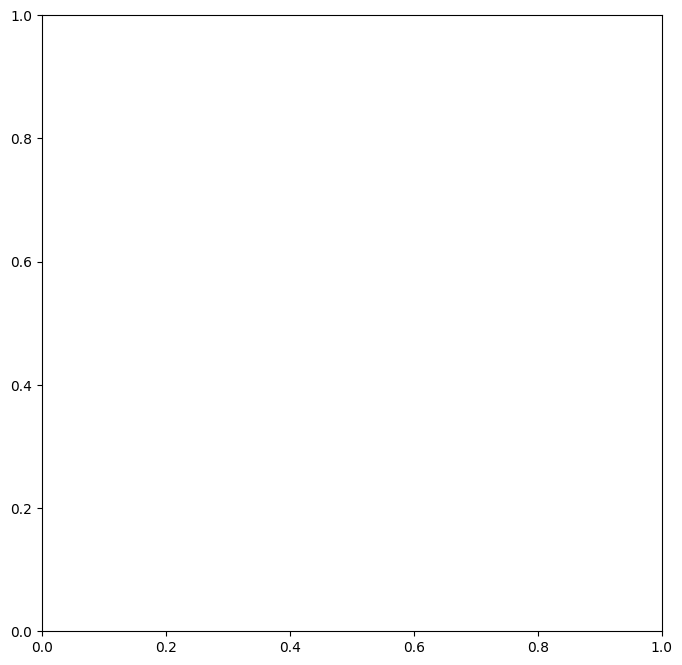

In [26]:
# Thay vì tạo numpyfier mới, hãy lấy từ pipeline  
numpyfier_from_pipeline = data_pipe.named_steps['np']  
  
# Sử dụng numpyfier này để inverse transform  
mocap_data_restored = numpyfier_from_pipeline.inverse_transform(piped_data)  
  
# Visualize  
from pymo.viz_tools import draw_stickfigure  
draw_stickfigure(mocap_data_restored[0], frame=100,   
                data=mocap_data_restored[0].values)

Available joints: ['Hips', 'Spine', 'Spine1', 'Spine2', 'Spine3', 'Neck', 'Neck1', 'Head', 'HeadEnd', 'HeadEnd_Nub', 'RightShoulder', 'RightArm', 'RightForeArm', 'RightHand', 'RightHandMiddle1', 'RightHandMiddle2', 'RightHandMiddle3', 'RightHandMiddle4', 'RightHandMiddle4_Nub', 'RightHandRing', 'RightHandRing1', 'RightHandRing2', 'RightHandRing3', 'RightHandRing4', 'RightHandRing4_Nub', 'RightHandPinky', 'RightHandPinky1', 'RightHandPinky2', 'RightHandPinky3', 'RightHandPinky4', 'RightHandPinky4_Nub', 'RightHandIndex', 'RightHandIndex1', 'RightHandIndex2', 'RightHandIndex3', 'RightHandIndex4', 'RightHandIndex4_Nub', 'RightHandThumb1', 'RightHandThumb2', 'RightHandThumb3', 'RightHandThumb4', 'RightHandThumb4_Nub', 'LeftShoulder', 'LeftArm', 'LeftForeArm', 'LeftHand', 'LeftHandMiddle1', 'LeftHandMiddle2', 'LeftHandMiddle3', 'LeftHandMiddle4', 'LeftHandMiddle4_Nub', 'LeftHandRing', 'LeftHandRing1', 'LeftHandRing2', 'LeftHandRing3', 'LeftHandRing4', 'LeftHandRing4_Nub', 'LeftHandPinky', 'L

KeyError: 'Hips_Xposition'

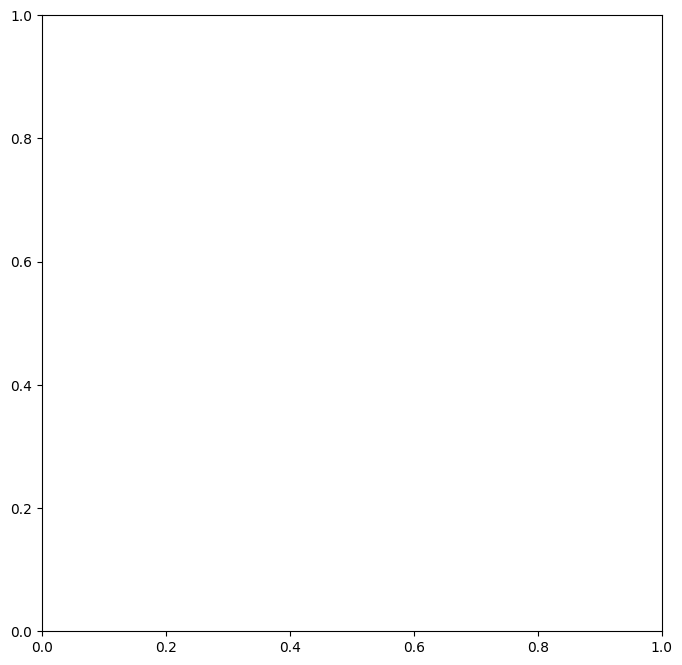

In [27]:
# Xem tất cả joints có sẵn  
available_joints = list(mocap_data_restored[0].skeleton.keys())  
print("Available joints:", available_joints)  
  
# Thử với joint đầu tiên (thường là root)  
if available_joints:  
    draw_stickfigure(mocap_data_restored[0], frame=100, joints=[available_joints[0]])

/home/ltdoanh/ldtan/Motion_Diffusion/datasets/pymo/viz_tools.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.scatter(x=df['%s_Xposition'%joint][frame],
/home/ltdoanh/ldtan/Motion_Diffusion/datasets/pymo/viz_tools.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y=df['%s_Yposition'%joint][frame],
/home/ltdoanh/ldtan/Motion_Diffusion/datasets/pymo/viz_tools.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  parent_x = df

<AxesSubplot:>

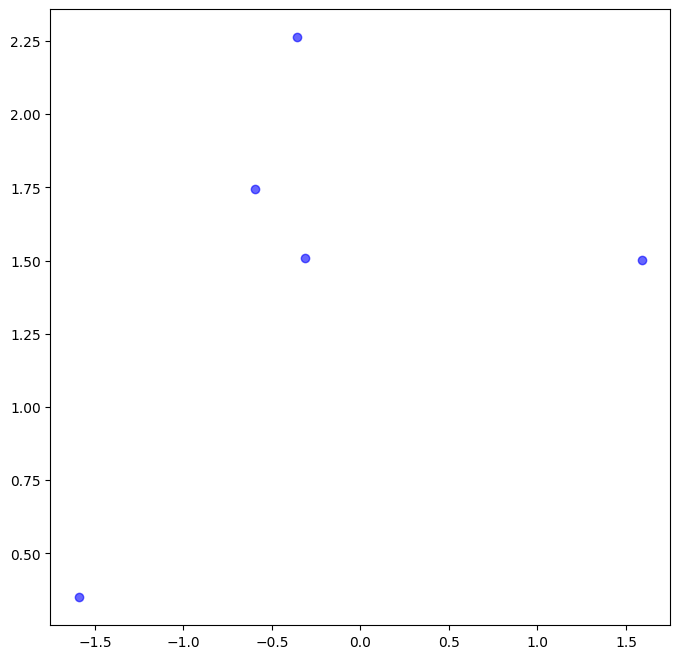

In [28]:
# Thử với joints không phải root  
main_joints = ['Spine', 'RightArm', 'LeftArm', 'RightUpLeg', 'LeftUpLeg']  
draw_stickfigure(mocap_data_restored[0], frame=100, joints=main_joints)

In [16]:
!pip install textgrid

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'textgrid' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'textgrid'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for textgrid: filename=TextGrid-1.6.1-py3-none-any.whl size=10147 sha256=1c79c5834d8ca43850d74a163fd7b146cf55507a4c7c6e79f12244b2a3fdd943
  Stored in directory: /home/ltdoanh/.cache/pip/wheels/23/41/f2/e2ef1817bd163de3c21dd078966bdd71bd5c4455841f4ec016
Successfully built textgrid


In [10]:
from emage_utils import fast_render
fast_render.render_one_sequence_no_gt("/home/ltdoanh/ldtan/Motion_Diffusion/datasets/BEAT/beat_english_v0.2.1/beat_english_v0.2.1/1/1_wayne_0_1_1.bvh", "/home/ltdoanh/ldtan/Motion_Diffusion/datasets/BEAT/beat_english_v0.2.1/beat_english_v0.2.1/1/1_wayne_0_1_1.wav", "/result_video.mp4")

UnpicklingError: Failed to interpret file '/home/ltdoanh/ldtan/Motion_Diffusion/datasets/BEAT/beat_english_v0.2.1/beat_english_v0.2.1/1/1_wayne_0_1_1.bvh' as a pickle

In [ ]:
import bvh  
import numpy as np  
  
def read_bvh_to_motion_data(bvh_file_path):  
    with open(bvh_file_path) as f:  
        mocap = bvh.Bvh(f.read())  
      
    # Extract joint names và motion data  
    joint_names = mocap.get_joints_names()  
    frames = mocap.nframes  
    frame_time = mocap.frame_time  
      
    # Convert BVH data to numpy array  
    motion_data = []  
    for i in range(frames):  
        frame_data = []  
        for joint in joint_names:  
            if mocap.joint_channels(joint):  
                for channel in mocap.joint_channels(joint):  
                    frame_data.append(float(mocap.frame_joint_channel(i, joint, channel)))  
        motion_data.append(frame_data)  
      
    return np.array(motion_data)  
  
# Sử dụng  
motion_data_from_bvh = read_bvh_to_motion_data("/home/ltdoanh/ldtan/Motion_Diffusion/datasets/BEAT/beat_english_v0.2.1/beat_english_v0.2.1/1/1_wayne_0_1_1.bvh")

In [ ]:
from emage_utils.motion_io import beat_format_save  
# Chuyển đổi và lưu  
beat_format_save(  
    save_path="converted_motion.npz",  
    motion_data=motion_data_from_bvh,  # numpy array từ BVH  
    upsample=1  # nếu cần upsample  
)  
  
# Sau đó có thể sử dụng với fast_render  
from emage_utils import fast_render  
fast_render.render_one_sequence_no_gt(  
    "converted_motion.npz",   
    "./output/",   
    "audio.wav"  
)

AttributeError: 'str' object has no attribute 'shape'

In [ ]:
def parse_textgrid(textgrid_path):  
    """Parse TextGrid file để lấy word timing"""  
    intervals = []  
    with open(textgrid_path, 'r') as f:  
        content = f.read()  
        # Parse intervals với xmin, xmax và text  
        # Return list of (start_time, end_time, text)  
    return intervals

In [ ]:
def segment_motion_by_timing(motion_data, intervals, fps=30):  
    """Chia motion data theo timing intervals"""  
    segments = []  
    for start_time, end_time, text in intervals:  
        start_frame = int(start_time * fps)  
        end_frame = int(end_time * fps)  
        motion_segment = motion_data[start_frame:end_frame]  
        segments.append({  
            'motion': motion_segment,  
            'text': text,  
            'start_time': start_time,  
            'end_time': end_time  
        })  
    return segments

In [ ]:
from emage_utils.motion_io import beat_format_save  
  
for i, segment in enumerate(segments):  
    if segment['text'].strip():  # Chỉ lưu segments có text  
        save_path = f"segment_{i}_{segment['text'][:10]}.npz"  
        beat_format_save(  
            save_path=save_path,  
            motion_data=segment['motion']  
        )

In [ ]:
def time_to_frame(t, fps=60):
    return int(round(t * fps))
